# Seleksi Fitur — Mutual Information
**Target:** `HadAngina` (CVDCRHD4) = Angina / Coronary Heart Disease  
**Dibuang dari fitur:** `HadAngina` (target), `HadHeartAttack` (data leakage), `State` (tidak relevan geografis)  
**Jumlah fitur k:** dipilih **otomatis** oleh algoritma via 5-Fold CV pada seluruh rentang k yang valid secara arsitektur CNN-LSTM  
**Encoding:** OrdinalEncoder dengan mapping eksplisit untuk fitur ordinal; LabelEncoder untuk fitur biner/nominal

## 1. Import Library & Load Data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv('heart_no_nans.csv')
print(f'Shape dataset : {df.shape}')
print(f'Kolom tersedia: {df.columns.tolist()}')

Shape dataset : (246022, 40)
Kolom tersedia: ['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']


## 2. Tentukan Target & Kolom yang Dibuang

In [5]:
# ✅ TARGET YANG BENAR:
# HadAngina = CVDCRHD4 = '(Ever told) you had angina or coronary heart disease'
TARGET    = 'HadAngina'

# Kolom yang DIBUANG:
# - HadAngina      : TARGET — tidak boleh jadi fitur
# - HadHeartAttack : komplikasi CHD → data leakage
# - State          : kode negara bagian AS → tidak relevan untuk Indonesia
DROP_COLS = [TARGET, 'HadHeartAttack', 'State']

print(f'Target        : {TARGET}')
print(f'Kolom dibuang : {DROP_COLS}')
print(f'\nDistribusi target:')
print(df[TARGET].value_counts())
print(f'Prevalensi CHD: {(df[TARGET]=="Yes").mean()*100:.2f}%')

Target        : HadAngina
Kolom dibuang : ['HadAngina', 'HadHeartAttack', 'State']

Distribusi target:
HadAngina
No     231069
Yes     14953
Name: count, dtype: int64
Prevalensi CHD: 6.08%


## 3. Encoding yang Tepat untuk Mutual Information

**Mengapa encoding penting untuk MI?**  
Mutual Information mengukur entropi bersama antara fitur dan target.  
Jika fitur ordinal dikode sembarangan, estimasi MI menjadi bias.  

**Strategi encoding yang digunakan:**  
- **Fitur ORDINAL** (ada urutan alami): `OrdinalEncoder` dengan mapping eksplisit  
  → Contoh: `GeneralHealth` (Excellent > Good > Fair > Poor), `AgeCategory`  
- **Fitur BINER** (Yes/No, Male/Female): `LabelEncoder` → kode 0/1, valid karena hanya 2 nilai  
- **Fitur NOMINAL** dengan banyak kategori: `LabelEncoder` dengan catatan keterbatasan  
  → Untuk dataset BRFSS ini, dampaknya minimal karena MI tetap divalidasi via 5-Fold CV

In [7]:
df_work = df.copy()

# --- Encode TARGET secara eksplisit (Yes=1, No=0) ---
df_work[TARGET] = df_work[TARGET].map({'Yes': 1, 'No': 0})
if df_work[TARGET].isnull().any():
    raise ValueError(f'Nilai tak terduga di kolom {TARGET}: {df[TARGET].unique()}')
y = df_work[TARGET]

# --- Pisahkan fitur (drop TARGET + leakage cols) ---
X_raw = df_work.drop(columns=DROP_COLS).copy()

# ============================================================
# DEFINISI TIPE ENCODING PER KOLOM
# Didasarkan pada codebook BRFSS 2022 dan sifat alami variabel
# ============================================================

# Fitur ORDINAL: ada urutan alami yang bermakna
# OrdinalEncoder dengan mapping eksplisit agar MI tidak bias
ORDINAL_MAPPINGS = {
    'GeneralHealth': ['Poor', 'Fair', 'Good', 'Very good', 'Excellent'],
    'AgeCategory':   ['Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34',
                      'Age 35 to 39', 'Age 40 to 44', 'Age 45 to 49',
                      'Age 50 to 54', 'Age 55 to 59', 'Age 60 to 64',
                      'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79',
                      'Age 80 or older'],
    'LastCheckupTime': ['Never', 'Within past 5 years (2 years but less than 5 years ago)',
                        'Within past 2 years (1 year but less than 2 years ago)',
                        'Within past year (anytime less than 12 months ago)'],
    'RemovedTeeth':  ['None of them', '1 to 5', '6 or more, but not all', 'All'],
    'SmokerStatus':  ['Never smoked', 'Former smoker',
                      'Current smoker - now smokes some days',
                      'Current smoker - now smokes every day'],
    'ECigaretteUsage': ['Never used e-cigarettes in my entire life',
                        'Not at all (right now)',
                        'Use them some days',
                        'Use them every day'],
    'HadDiabetes':   ['No', 'No, pre-diabetes or borderline diabetes',
                      'Yes, but female told only during pregnancy',
                      'Yes'],
}

encoders    = {}   # simpan semua encoder untuk backend
ordinal_cols = list(ORDINAL_MAPPINGS.keys())

# --- Encode ORDINAL columns ---
for col, categories in ORDINAL_MAPPINGS.items():
    if col not in X_raw.columns:
        continue
    oe = OrdinalEncoder(categories=[categories],
                        handle_unknown='use_encoded_value',
                        unknown_value=-1)
    X_raw[[col]] = oe.fit_transform(X_raw[[col]])
    encoders[col] = oe

# --- Encode kolom OBJECT yang tersisa (biner atau nominal) dengan LabelEncoder ---
# Kolom biner (2 nilai): LabelEncoder valid (0/1 tidak memunculkan asumsi ordinal)
# Kolom nominal (>2 nilai): LabelEncoder dengan keterbatasan yang dicatat
nominal_cols = []
for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        n_unique = X_raw[col].nunique()
        le = LabelEncoder()
        X_raw[col] = le.fit_transform(X_raw[col].astype(str))
        encoders[col] = le
        if n_unique > 2:
            nominal_cols.append(col)

X_full = X_raw.copy()

# Validasi
assert X_full.isnull().sum().sum() == 0, 'Terdapat NaN di X_full!'

print(f'Jumlah fitur (setelah drop) : {X_full.shape[1]}')
print(f'\nKolom dengan OrdinalEncoder ({len(ordinal_cols)}): {ordinal_cols}')
print(f'Kolom dengan LabelEncoder nominal (>{2} nilai) ({len(nominal_cols)}): {nominal_cols}')
print(f'\nDistribusi y (0=Non-CHD, 1=CHD):')
print(y.value_counts())
print(f'Prevalensi CHD: {y.mean()*100:.2f}%')

# Simpan encoder untuk backend
joblib.dump(encoders, 'encoders_mi.pkl')
print('\n✅ encoders_mi.pkl tersimpan')

Jumlah fitur (setelah drop) : 37

Kolom dengan OrdinalEncoder (7): ['GeneralHealth', 'AgeCategory', 'LastCheckupTime', 'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'HadDiabetes']
Kolom dengan LabelEncoder nominal (>2 nilai) (3): ['RaceEthnicityCategory', 'TetanusLast10Tdap', 'CovidPos']

Distribusi y (0=Non-CHD, 1=CHD):
HadAngina
0    231069
1     14953
Name: count, dtype: int64
Prevalensi CHD: 6.08%

✅ encoders_mi.pkl tersimpan


## 4. Mutual Information Score — Ranking Semua Fitur

**Mutual Information (MI)** mengukur seberapa besar informasi (dalam bit) yang dibagikan  
antara satu fitur dengan target `HadAngina`, berdasarkan **Teori Informasi Entropi Shannon**.  

Keunggulan MI dibanding metode lain:  
- Menangkap **hubungan non-linear** (berbeda dengan korelasi Pearson yang hanya linear)  
- **Model-agnostic**: tidak bias terhadap model tertentu  
- Bekerja untuk **data numerik maupun kategorikal**

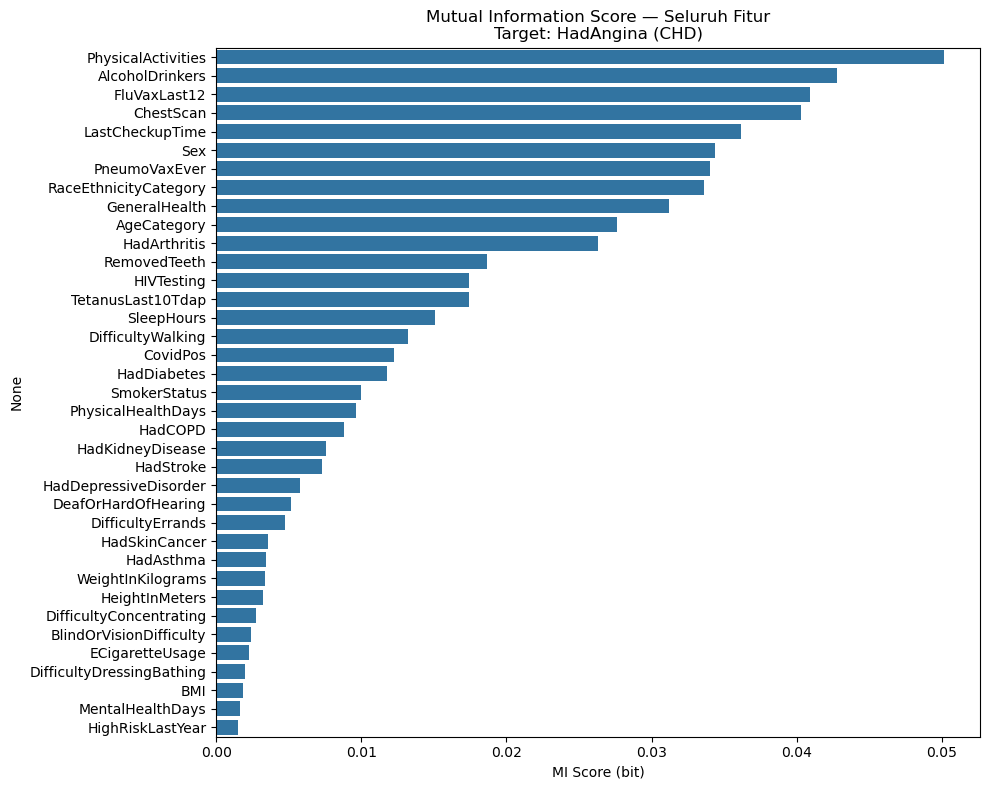

Ranking seluruh fitur berdasarkan MI Score:
PhysicalActivities           0.050126
AlcoholDrinkers              0.042772
FluVaxLast12                 0.040887
ChestScan                    0.040314
LastCheckupTime              0.036129
Sex                          0.034404
PneumoVaxEver                0.034055
RaceEthnicityCategory        0.033615
GeneralHealth                0.031167
AgeCategory                  0.027610
HadArthritis                 0.026292
RemovedTeeth                 0.018624
HIVTesting                   0.017431
TetanusLast10Tdap            0.017392
SleepHours                   0.015104
DifficultyWalking            0.013180
CovidPos                     0.012257
HadDiabetes                  0.011776
SmokerStatus                 0.009963
PhysicalHealthDays           0.009661
HadCOPD                      0.008781
HadKidneyDisease             0.007537
HadStroke                    0.007291
HadDepressiveDisorder        0.005752
DeafOrHardOfHearing          0.005139
Diffic

In [9]:
# Hitung MI score untuk semua fitur
# discrete_features='auto': mendeteksi otomatis fitur diskrit (integer) vs kontinu
mi_scores = mutual_info_classif(
    X_full, y,
    discrete_features='auto',
    random_state=42
)

mi_series        = pd.Series(mi_scores, index=X_full.columns)
mi_series_sorted = mi_series.sort_values(ascending=False)

# Plot seluruh fitur
plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series_sorted.values, y=mi_series_sorted.index)
plt.title('Mutual Information Score — Seluruh Fitur\nTarget: HadAngina (CHD)')
plt.xlabel('MI Score (bit)')
plt.tight_layout()
plt.show()

print('Ranking seluruh fitur berdasarkan MI Score:')
print(mi_series_sorted.to_string())

## 5. Pemilihan k Optimal secara Otomatis (AI yang Memutuskan)

**Catatan metodologis — Hybrid Filter-Wrapper:**  
MI adalah *Filter Method* (menilai fitur secara univariate, independen dari model).  
Untuk mengatasi kelemahan sifat univariate MI (tidak melihat interaksi antarfitur),  
kami menambahkan tahap *Wrapper* berbasis **5-Fold Cross-Validation**:  
top-k fitur dari ranking MI dievaluasi secara kolektif menggunakan RandomForest.  
Algoritma sendiri yang memilih k berdasarkan ROC-AUC tertinggi.

**Justifikasi batas bawah K_MIN = 5:**  
`Conv1D(kernel_size=2)` → output = k-1. `MaxPooling1D(pool_size=2)` butuh input ≥ 2  
→ (k-1) ≥ 2 → k ≥ 3. Margin keamanan arsitektur → **K_MIN = 5**.  
**Batas atas = semua fitur tersedia** — tanpa intervensi manusia.

In [11]:
K_MIN = 5
K_MAX = len(X_full.columns)   # semua fitur, AI yang memutuskan

print(f'Rentang pencarian k : {K_MIN} .. {K_MAX}')
print(f'Total iterasi CV    : {K_MAX - K_MIN + 1}')
print('=' * 55)

results = []

for k in range(K_MIN, K_MAX + 1):
    top_k = mi_series_sorted.index[:k].tolist()
    X_k   = X_full[top_k]

    rf_cv    = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=1)
    cv_aucs  = cross_val_score(rf_cv, X_k, y, cv=5, scoring='roc_auc')
    mean_auc = cv_aucs.mean()
    std_auc  = cv_aucs.std()

    results.append({
        'k'        : k,
        'features' : top_k,
        'mean_auc' : mean_auc,
        'std_auc'  : std_auc
    })
    print(f'k={k:2d} → CV ROC-AUC = {mean_auc:.4f} (±{std_auc:.4f})')

best              = max(results, key=lambda x: x['mean_auc'])
best_k            = best['k']
best_auc          = best['mean_auc']
selected_features = best['features']

print('=' * 55)
print(f'\n✅ k optimal (dipilih algoritma): {best_k} fitur')
print(f'   CV ROC-AUC tertinggi         : {best_auc:.4f}')
print(f'\nFitur terpilih ({best_k} fitur):')
for i, f in enumerate(selected_features, 1):
    enc_type = 'OrdinalEncoder' if f in ordinal_cols else ('LabelEncoder' if f in encoders else 'Numerik')
    print(f'  {i:2d}. {f:<35s} MI={mi_series_sorted[f]:.5f}  [{enc_type}]')

Rentang pencarian k : 5 .. 37
Total iterasi CV    : 33
k= 5 → CV ROC-AUC = 0.7495 (±0.0040)
k= 6 → CV ROC-AUC = 0.7645 (±0.0035)
k= 7 → CV ROC-AUC = 0.7835 (±0.0042)
k= 8 → CV ROC-AUC = 0.7790 (±0.0051)
k= 9 → CV ROC-AUC = 0.7967 (±0.0043)
k=10 → CV ROC-AUC = 0.7898 (±0.0050)
k=11 → CV ROC-AUC = 0.7796 (±0.0056)
k=12 → CV ROC-AUC = 0.7636 (±0.0056)
k=13 → CV ROC-AUC = 0.7606 (±0.0037)
k=14 → CV ROC-AUC = 0.7588 (±0.0030)
k=15 → CV ROC-AUC = 0.7697 (±0.0031)
k=16 → CV ROC-AUC = 0.7734 (±0.0025)
k=17 → CV ROC-AUC = 0.7804 (±0.0042)
k=18 → CV ROC-AUC = 0.7905 (±0.0029)
k=19 → CV ROC-AUC = 0.7979 (±0.0019)
k=20 → CV ROC-AUC = 0.8036 (±0.0033)
k=21 → CV ROC-AUC = 0.8086 (±0.0037)
k=22 → CV ROC-AUC = 0.8106 (±0.0050)
k=23 → CV ROC-AUC = 0.8157 (±0.0034)
k=24 → CV ROC-AUC = 0.8159 (±0.0060)
k=25 → CV ROC-AUC = 0.8177 (±0.0039)
k=26 → CV ROC-AUC = 0.8192 (±0.0038)
k=27 → CV ROC-AUC = 0.8187 (±0.0051)
k=28 → CV ROC-AUC = 0.8212 (±0.0044)
k=29 → CV ROC-AUC = 0.8260 (±0.0048)
k=30 → CV ROC-AUC = 

## 6. Visualisasi Kurva k vs ROC-AUC & MI Score Fitur Terpilih

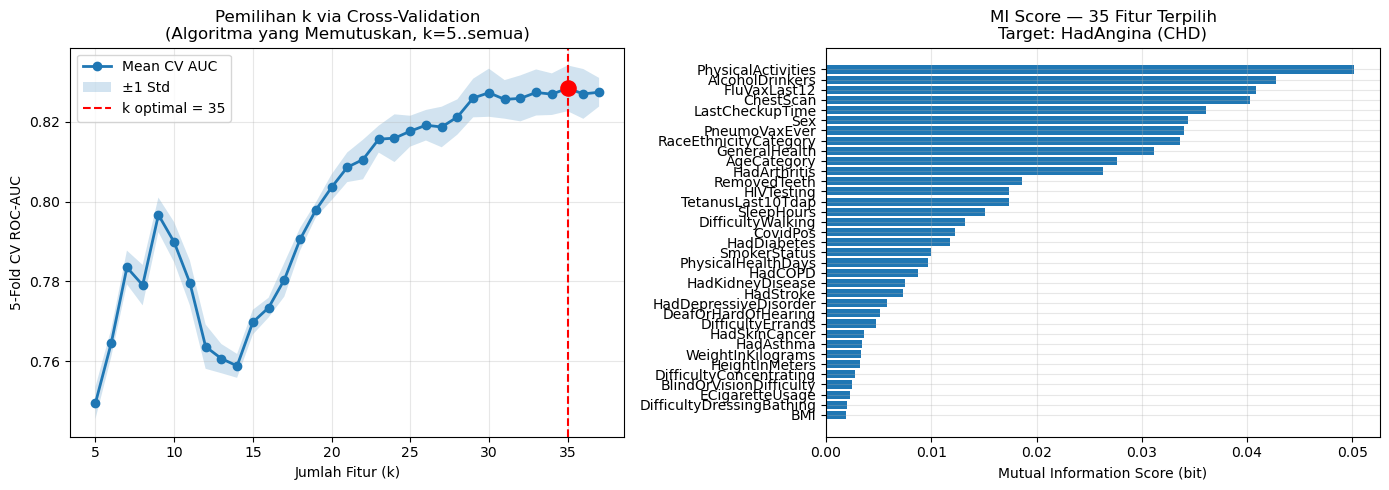

In [13]:
ks   = [r['k']        for r in results]
aucs = [r['mean_auc'] for r in results]
stds = [r['std_auc']  for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

aucs_arr = np.array(aucs)
stds_arr = np.array(stds)
axes[0].plot(ks, aucs, marker='o', linewidth=2, label='Mean CV AUC')
axes[0].fill_between(ks, aucs_arr-stds_arr, aucs_arr+stds_arr,
                     alpha=0.2, label='±1 Std')
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'k optimal = {best_k}')
axes[0].scatter([best_k], [best_auc], color='red', s=120, zorder=5)
axes[0].set_xlabel('Jumlah Fitur (k)')
axes[0].set_ylabel('5-Fold CV ROC-AUC')
axes[0].set_title('Pemilihan k via Cross-Validation\n(Algoritma yang Memutuskan, k=5..semua)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sel_mi = mi_series_sorted[selected_features]
axes[1].barh(sel_mi.index[::-1], sel_mi.values[::-1])
axes[1].set_xlabel('Mutual Information Score (bit)')
axes[1].set_title(f'MI Score — {best_k} Fitur Terpilih\nTarget: HadAngina (CHD)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Persiapan Data Training

In [15]:
X_selected = X_full[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

assert not np.isnan(X_train_scaled).any(), 'NaN ditemukan setelah scaling!'
assert not np.isinf(X_train_scaled).any(), 'Inf ditemukan setelah scaling!'
print('✅ Tidak ada NaN/Inf setelah scaling')

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1],  1)

print(f'X_train : {X_train_lstm.shape}')
print(f'X_test  : {X_test_lstm.shape}')
print(f'Fitur   : {best_k} (dipilih otomatis oleh algoritma via MI + CV)')
print(f'List    : {selected_features}')

✅ Tidak ada NaN/Inf setelah scaling
X_train : (196817, 35, 1)
X_test  : (49205, 35, 1)
Fitur   : 35 (dipilih otomatis oleh algoritma via MI + CV)
List    : ['PhysicalActivities', 'AlcoholDrinkers', 'FluVaxLast12', 'ChestScan', 'LastCheckupTime', 'Sex', 'PneumoVaxEver', 'RaceEthnicityCategory', 'GeneralHealth', 'AgeCategory', 'HadArthritis', 'RemovedTeeth', 'HIVTesting', 'TetanusLast10Tdap', 'SleepHours', 'DifficultyWalking', 'CovidPos', 'HadDiabetes', 'SmokerStatus', 'PhysicalHealthDays', 'HadCOPD', 'HadKidneyDisease', 'HadStroke', 'HadDepressiveDisorder', 'DeafOrHardOfHearing', 'DifficultyErrands', 'HadSkinCancer', 'HadAsthma', 'WeightInKilograms', 'HeightInMeters', 'DifficultyConcentrating', 'BlindOrVisionDifficulty', 'ECigaretteUsage', 'DifficultyDressingBathing', 'BMI']


## 8. Arsitektur CNN-LSTM

In [17]:
n_features = X_train_lstm.shape[1]

model = Sequential([
    Input(shape=(n_features, 1)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(50, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 34, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,243 (90.79 KB)

 Trainable params: 23,243 (90.79 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Training dengan Class Weighting & Early Stopping

In [19]:
classes = np.unique(y_train)
cw_arr  = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw_arr))
print(f'Class weights: {cw_dict}')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_lstm, y_train,
    epochs           = 100,
    batch_size       = 32,
    validation_split = 0.2,
    class_weight     = cw_dict,
    callbacks        = [early_stop],
    verbose          = 1
)

loss, acc = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f'\nTest Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')

Class weights: {0: 0.5323550891239079, 1: 8.226759739174051}
Epoch 1/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.6903 - loss: 0.5506 - val_accuracy: 0.6904 - val_loss: 0.5684
Epoch 2/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.7055 - loss: 0.5235 - val_accuracy: 0.7012 - val_loss: 0.5250
Epoch 3/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.7117 - loss: 0.5116 - val_accuracy: 0.6472 - val_loss: 0.6292
Epoch 4/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.7190 - loss: 0.4975 - val_accuracy: 0.6659 - val_loss: 0.5547
Epoch 5/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - accuracy: 0.7226 - loss: 0.4933 - val_accuracy: 0.7166 - val_loss: 0.4891
Epoch 6/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.7286 - loss: 0.4901 - val_accuracy: 0.6972 - val_loss: 0.5367
Epoch 7/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.7314 - loss: 0.4842 - val_accuracy: 0.7807 - val_loss: 0.4632
Epoch 8/100
492

## 10. Evaluasi Model

1538/1538 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Classification Report (Target: HadAngina / CHD):
              precision    recall  f1-score   support

     Non-CHD       0.98      0.76      0.86     46214
         CHD       0.17      0.78      0.28      2991

    accuracy                           0.76     49205
   macro avg       0.58      0.77      0.57     49205
weighted avg       0.93      0.76      0.82     49205

ROC-AUC Score : 0.8515


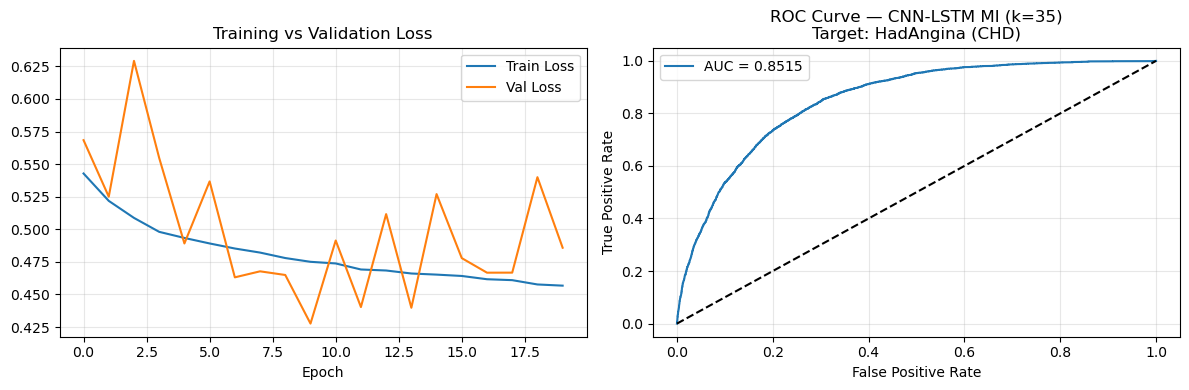

In [21]:
y_proba = model.predict(X_test_lstm).flatten()
y_pred  = (y_proba > 0.5).astype(int)

print('Classification Report (Target: HadAngina / CHD):')
print(classification_report(y_test, y_pred, target_names=['Non-CHD', 'CHD']))

roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score : {roc_auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — CNN-LSTM MI (k={best_k})\nTarget: HadAngina (CHD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Baseline Model — Perbandingan CNN-LSTM vs Random Forest Murni
Setelah CNN-LSTM selesai dilatih, kami membandingkan performanya dengan **Random Forest murni**  
pada fitur yang sama. Ini menjawab pertanyaan: *'Apakah CNN-LSTM memberikan nilai tambah dibanding model klasik?'*

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Baseline: Random Forest murni pada fitur yang sama dengan CNN-LSTM
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_rf_base  = rf_baseline.predict(X_test)
y_proba_rf_base = rf_baseline.predict_proba(X_test)[:, 1]
auc_rf_base     = roc_auc_score(y_test, y_proba_rf_base)

print('='*55)
print('BASELINE — Random Forest Murni (fitur yang sama)')
print('='*55)
print(classification_report(y_test, y_pred_rf_base, target_names=['Non-CHD','CHD']))
print(f'ROC-AUC RF Baseline : {auc_rf_base:.4f}')
print()
print('='*55)
print('CNN-LSTM (model utama)')
print('='*55)
print(classification_report(y_test, y_pred, target_names=['Non-CHD','CHD']))
print(f'ROC-AUC CNN-LSTM    : {roc_auc:.4f}')
print()
print('--- Perbandingan ---')
print(f'Delta ROC-AUC (CNN-LSTM - RF): {roc_auc - auc_rf_base:+.4f}')
if roc_auc > auc_rf_base:
    print('✅ CNN-LSTM lebih unggul dari RF biasa')
elif roc_auc == auc_rf_base:
    print('⚠️  CNN-LSTM setara dengan RF biasa')
else:
    print('⚠️  RF biasa lebih unggul — perlu justifikasi penggunaan CNN-LSTM')

BASELINE — Random Forest Murni (fitur yang sama)
              precision    recall  f1-score   support

     Non-CHD       0.94      1.00      0.97     46214
         CHD       0.53      0.02      0.03      2991

    accuracy                           0.94     49205
   macro avg       0.73      0.51      0.50     49205
weighted avg       0.92      0.94      0.91     49205

ROC-AUC RF Baseline : 0.8411

CNN-LSTM (model utama)
              precision    recall  f1-score   support

     Non-CHD       0.98      0.76      0.86     46214
         CHD       0.17      0.78      0.28      2991

    accuracy                           0.76     49205
   macro avg       0.58      0.77      0.57     49205
weighted avg       0.93      0.76      0.82     49205

ROC-AUC CNN-LSTM    : 0.8515

--- Perbandingan ---
Delta ROC-AUC (CNN-LSTM - RF): +0.0103
✅ CNN-LSTM lebih unggul dari RF biasa


## Threshold Tuning — Analisis Trade-off Presisi vs Recall
Threshold default 0.5 menghasilkan presisi CHD yang rendah (karena class imbalance).  
Di sini kita analisis trade-off: **naikkan threshold → presisi naik, recall turun**.  
Untuk skrining medis, **recall lebih penting** (hindari pasien CHD tidak terdeteksi).

 Threshold |  Precision |     Recall |         F1
------------------------------------------------
      0.20 |     0.1166 |     0.9341 |     0.2074
      0.25 |     0.1242 |     0.9204 |     0.2189
      0.30 |     0.1322 |     0.9007 |     0.2306
      0.35 |     0.1409 |     0.8830 |     0.2430
      0.40 |     0.1508 |     0.8582 |     0.2566
      0.45 |     0.1611 |     0.8238 |     0.2695
      0.50 |     0.1734 |     0.7840 |     0.2841
      0.55 |     0.1913 |     0.7392 |     0.3039
      0.60 |     0.2097 |     0.6787 |     0.3204
      0.65 |     0.2309 |     0.6025 |     0.3339
      0.70 |     0.2626 |     0.5192 |     0.3488

✅ Threshold optimal (F1 tertinggi): 0.70
   Precision = 0.2626
   Recall    = 0.5192
   F1-Score  = 0.3488


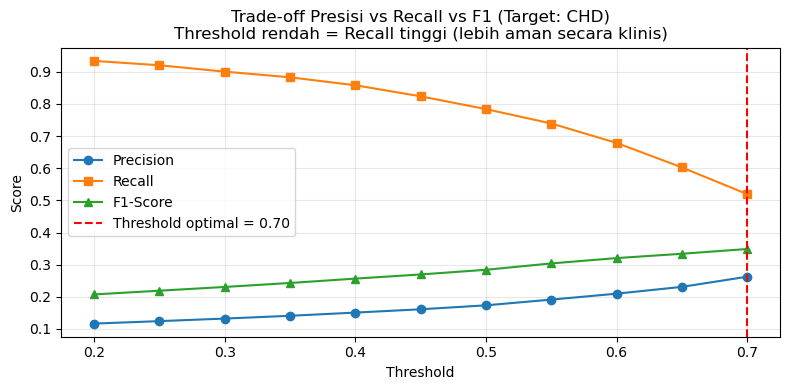

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

thresholds  = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
thr_results = []

print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>10} | {"F1":>10}')
print('-' * 48)

for thr in thresholds:
    y_t = (y_proba > thr).astype(int)
    # Hindari division by zero jika semua prediksi satu kelas
    try:
        prec = precision_score(y_test, y_t, zero_division=0)
        rec  = recall_score(y_test, y_t,    zero_division=0)
        f1   = f1_score(y_test, y_t,         zero_division=0)
    except:
        prec = rec = f1 = 0.0
    thr_results.append({'thr': thr, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f'{thr:>10.2f} | {prec:>10.4f} | {rec:>10.4f} | {f1:>10.4f}')

# Threshold dengan F1 tertinggi
best_thr = max(thr_results, key=lambda x: x['f1'])
print(f'\n✅ Threshold optimal (F1 tertinggi): {best_thr["thr"]:.2f}')
print(f'   Precision = {best_thr["precision"]:.4f}')
print(f'   Recall    = {best_thr["recall"]:.4f}')
print(f'   F1-Score  = {best_thr["f1"]:.4f}')

# Plot
plt.figure(figsize=(8, 4))
thrs  = [r['thr']       for r in thr_results]
precs = [r['precision'] for r in thr_results]
recs  = [r['recall']    for r in thr_results]
f1s   = [r['f1']        for r in thr_results]
plt.plot(thrs, precs, marker='o', label='Precision')
plt.plot(thrs, recs,  marker='s', label='Recall')
plt.plot(thrs, f1s,   marker='^', label='F1-Score')
plt.axvline(x=best_thr['thr'], color='red', linestyle='--',
            label=f'Threshold optimal = {best_thr["thr"]:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Trade-off Presisi vs Recall vs F1 (Target: CHD)\n'
          'Threshold rendah = Recall tinggi (lebih aman secara klinis)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Simpan Semua Artefak

In [27]:
# Model CNN-LSTM
model.save('model_mi_cnn_lstm.keras')
print('✅ model_mi_cnn_lstm.keras')

# Scaler
joblib.dump(scaler, 'scaler_mi.pkl')
print('✅ scaler_mi.pkl')

# Encoder — hanya untuk fitur terpilih
encoders_used = {col: encoders[col] for col in selected_features if col in encoders}
joblib.dump(encoders_used, 'encoders_mi.pkl')
print(f'✅ encoders_mi.pkl  ({len(encoders_used)} encoder dari {best_k} fitur terpilih)')

# Simpan juga info tipe encoder per kolom (untuk backend)
encoder_types = {}
for col in selected_features:
    if col in ordinal_cols:   encoder_types[col] = 'OrdinalEncoder'
    elif col in encoders:     encoder_types[col] = 'LabelEncoder'
    else:                     encoder_types[col] = 'Numerik'

# Metadata
metadata_mi = {
    'target'            : TARGET,
    'dropped_cols'      : DROP_COLS,
    'selected_features' : selected_features,
    'n_features'        : best_k,
    'k_search_range'    : [K_MIN, K_MAX],
    'method'            : 'Mutual Information (Hybrid Filter-Wrapper) + 5-Fold CV (k=5..semua)',
    'encoding_strategy' : 'OrdinalEncoder (ordinal cols) + LabelEncoder (biner/nominal)',
    'encoder_types'     : encoder_types,
    'best_cv_auc'       : round(best_auc, 4),
    'test_roc_auc'      : round(roc_auc, 4),
    'test_accuracy'     : round(float(acc), 4),
}
joblib.dump(metadata_mi, 'metadata_mi.pkl')
print('✅ metadata_mi.pkl')

print('\n========== RINGKASAN AKHIR ==========')
print(f'Target          : {TARGET}')
print(f'Metode seleksi  : Mutual Information (Hybrid Filter-Wrapper) + 5-Fold CV')
print(f'Encoding        : OrdinalEncoder (ordinal) + LabelEncoder (biner/nominal)')
print(f'Rentang k dicek : {K_MIN} .. {K_MAX} (semua fitur tersedia)')
print(f'k optimal       : {best_k} (dipilih otomatis oleh algoritma)')
print(f'CV ROC-AUC      : {best_auc:.4f}')
print(f'Test ROC-AUC    : {roc_auc:.4f}')
print(f'Test Accuracy   : {acc:.4f}')
print(f'Fitur terpilih  : {selected_features}')
print('=====================================')

✅ model_mi_cnn_lstm.keras
✅ scaler_mi.pkl
✅ encoders_mi.pkl  (30 encoder dari 35 fitur terpilih)
✅ metadata_mi.pkl

========== RINGKASAN AKHIR ==========
Target          : HadAngina
Metode seleksi  : Mutual Information (Hybrid Filter-Wrapper) + 5-Fold CV
Encoding        : OrdinalEncoder (ordinal) + LabelEncoder (biner/nominal)
Rentang k dicek : 5 .. 37 (semua fitur tersedia)
k optimal       : 35 (dipilih otomatis oleh algoritma)
CV ROC-AUC      : 0.8284
Test ROC-AUC    : 0.8515
Test Accuracy   : 0.7598
Fitur terpilih  : ['PhysicalActivities', 'AlcoholDrinkers', 'FluVaxLast12', 'ChestScan', 'LastCheckupTime', 'Sex', 'PneumoVaxEver', 'RaceEthnicityCategory', 'GeneralHealth', 'AgeCategory', 'HadArthritis', 'RemovedTeeth', 'HIVTesting', 'TetanusLast10Tdap', 'SleepHours', 'DifficultyWalking', 'CovidPos', 'HadDiabetes', 'SmokerStatus', 'PhysicalHealthDays', 'HadCOPD', 'HadKidneyDisease', 'HadStroke', 'HadDepressiveDisorder', 'DeafOrHardOfHearing', 'DifficultyErrands', 'HadSkinCancer', 'HadAs